# TASKS

In [2]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
#Step 2: Load Dataset
df = pd.read_csv("Titanic.csv")

df.head()

,Pclass,Sex,Age,Fare,Embarked,Survived
0,3,male,22,7.25,S,0
1,1,female,38,71.28,C,1
2,3,female,26,7.92,S,1
3,1,female,35,53.10,S,1
4,3,male,35,8.05,S,0


(15, 6)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    15 non-null     int64  
 1   Sex       15 non-null     str    
 2   Age       15 non-null     int64  
 3   Fare      15 non-null     float64
 4   Embarked  15 non-null     str    
 5   Survived  15 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 852.0 bytes


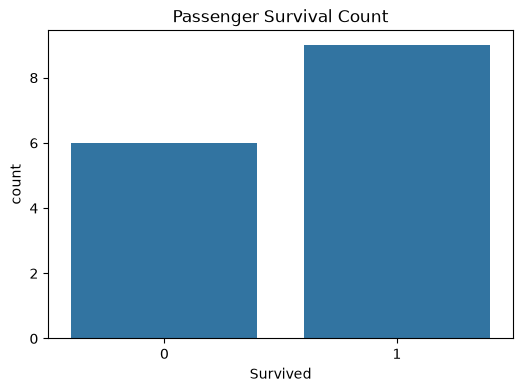

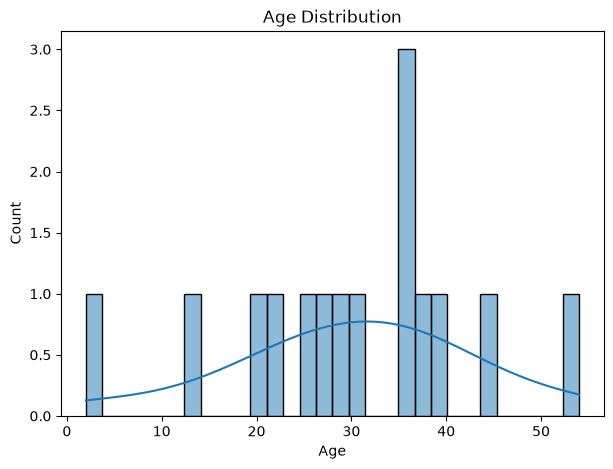

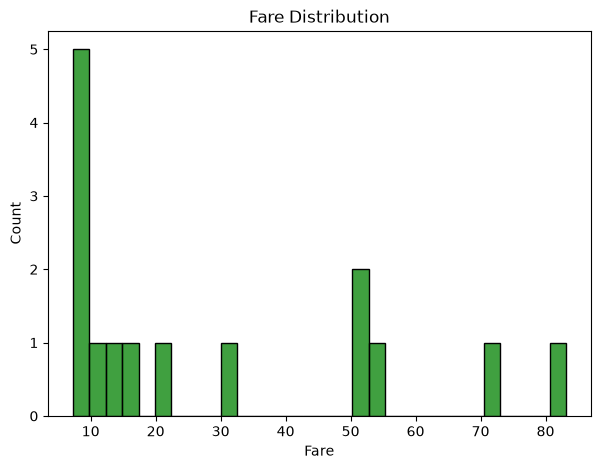

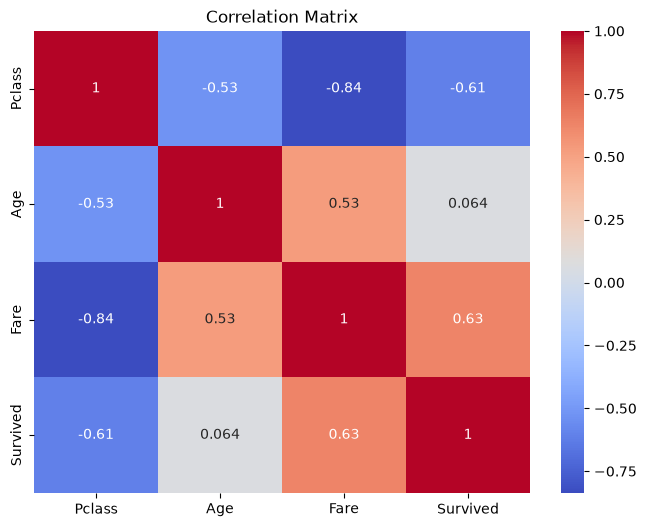

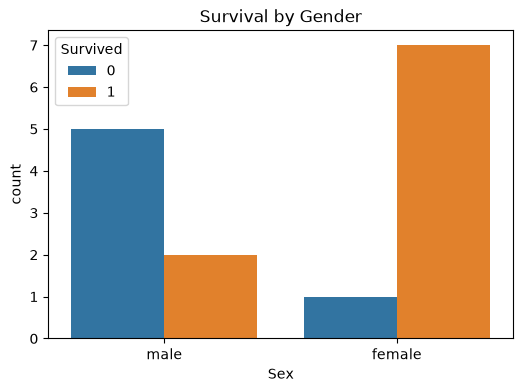

In [4]:
#Step 3: Exploratory Data Analysis (EDA)
#Dataset Shape
print(df.shape)
#Dataset Information
df.info()
#Missing Values
df.isnull().sum()
#Statistical Summary
df.describe()
#Duplicate Records
df.duplicated().sum()

#Five Required Visualizations
#1. Survival Count
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Count")
plt.show()

#2. Age Distribution
plt.figure(figsize=(7,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

#3. Fare Distribution
plt.figure(figsize=(7,5))

sns.histplot(df["Fare"], bins=30, color="green")

plt.title("Fare Distribution")
plt.show()

#4. Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

#5. Survival by Gender
plt.figure(figsize=(6,4))

sns.countplot(x="Sex",
              hue="Survived",
              data=df)

plt.title("Survival by Gender")
plt.show()

<Axes: >

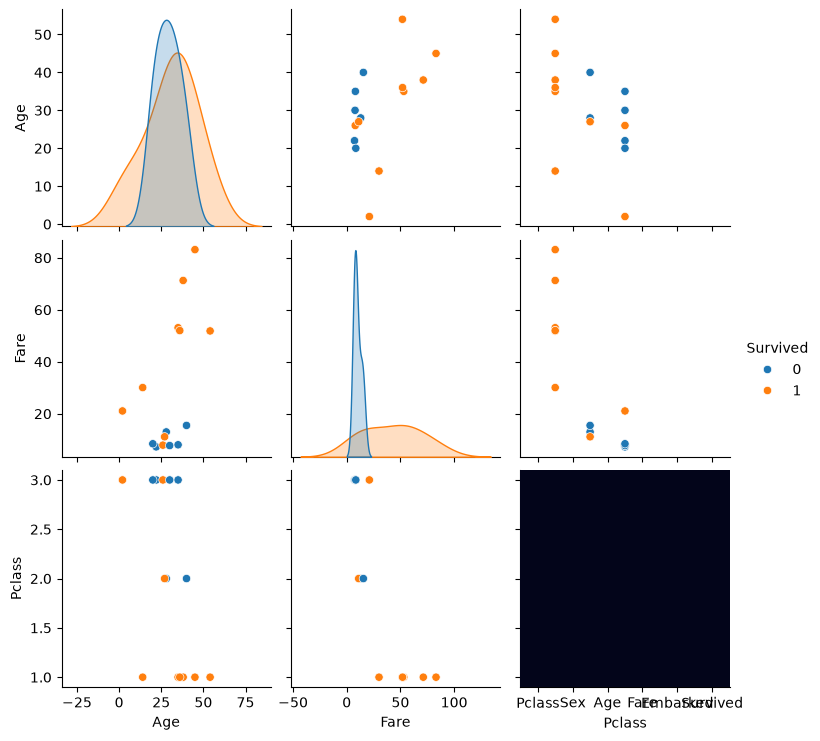

In [5]:
#Pairplot
sns.pairplot(df[["Age","Fare","Pclass","Survived"]], hue="Survived")
#Missing Value Heatmap
sns.heatmap(df.isnull(), cbar=False)

In [ ]:
# STEP 4 : DATA PREPROCESSING

# Create missing columns if they don't exist

if 'PassengerId' not in df.columns:
    df['PassengerId'] = range(1, len(df)+1)

if 'Name' not in df.columns:
    df['Name'] = ['Passenger_' + str(i) for i in range(len(df))]

if 'Ticket' not in df.columns:
    df['Ticket'] = ['T' + str(i) for i in range(len(df))]

if 'Cabin' not in df.columns:
    df['Cabin'] = 'Unknown'

# Display first five rows
print(df.head())

# Drop unnecessary columns
df = df.drop(columns=['PassengerId','Name','Ticket','Cabin'])

print("\nColumns after dropping:")
print(df.columns)

   Pclass     Sex  Age   Fare Embarked  Survived  PassengerId         Name  \
0       3    male   22   7.25        S         0            1  Passenger_0   
1       1  female   38  71.28        C         1            2  Passenger_1   
2       3  female   26   7.92        S         1            3  Passenger_2   
3       1  female   35  53.10        S         1            4  Passenger_3   
4       3    male   35   8.05        S         0            5  Passenger_4   

  Ticket    Cabin  
0     T0  Unknown  
1     T1  Unknown  
2     T2  Unknown  
3     T3  Unknown  
4     T4  Unknown  

Columns after dropping:
Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Survived'], dtype='str')


In [9]:
# ============================
# STEP 5 : PREPROCESSING
# ============================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical columns
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

# Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (12, 5)
X_test shape: (3, 5)


In [12]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression trained successfully!")

#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree trained successfully!")

#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [15]:
#Step 6: Cross Validation
cv_lr = cross_val_score(
    lr,
    X,
    y,
    cv=5
)

cv_dt = cross_val_score(
    dt,
    X,
    y,
    cv=5
)

cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5
)
print("Logistic Regression:", cv_lr.mean())

print("Decision Tree:", cv_dt.mean())

print("Random Forest:", cv_rf.mean())

Logistic Regression: 0.8
Decision Tree: 0.8
Random Forest: 0.7333333333333333


In [16]:
#Step 7: Model Evaluation
#Accuracy
print("Logistic Regression")

print(accuracy_score(y_test, pred_lr))

print("Decision Tree")

print(accuracy_score(y_test, pred_dt))

print("Random Forest")

print(accuracy_score(y_test, pred_rf))

#Confusion Matrix
print(confusion_matrix(y_test, pred_rf))

#Classification Report
print(classification_report(y_test, pred_rf))

Logistic Regression
1.0
Decision Tree
1.0
Random Forest
0.6666666666666666
[[1 1]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



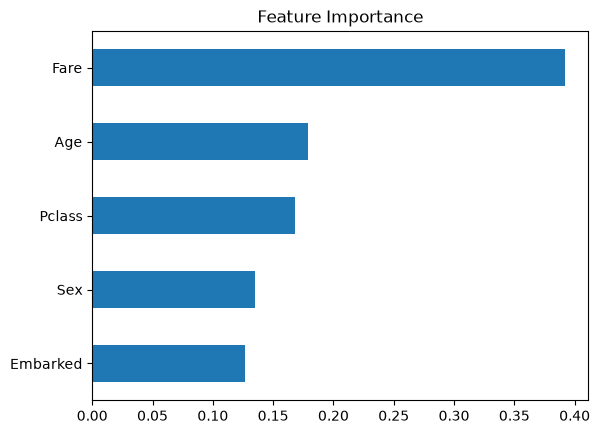

In [17]:
#Step 8: Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=df.drop("Survived", axis=1).columns
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

# PRACTICE

In [21]:
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
import warnings

# Suppress warnings for a cleaner CLI experience
warnings.filterwarnings('ignore')

def train_model():
    """
    Trains the SVC model on the Titanic dataset on startup. 
    In a true production environment, you would load a pre-trained model 
    using joblib or pickle instead of training it on the fly.
    """
    print("Initializing and training model...")
    df = sns.load_dataset('titanic')
    
    # Select features needed for prediction
    X = df[['pclass', 'sex', 'age', 'fare', 'embarked']]
    y = df['survived']

    # Set up the preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')), 
                ('scaler', StandardScaler())
            ]), ['pclass', 'age', 'fare']),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')), 
                ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
            ]), ['sex', 'embarked'])
        ])

    # Build and train the pipeline with probability=True to show confidence
    model = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', SVC(random_state=42, probability=True))
    ])
    
    model.fit(X, y)
    print("Model trained successfully!\n")
    return model

def get_user_input():
    """Prompts the user for passenger details via the command line."""
    print("--- Enter Passenger Details ---")
    
    while True:
        try:
            pclass = int(input("Passenger Class (1, 2, or 3): "))
            if pclass not in [1, 2, 3]: raise ValueError("Class must be 1, 2, or 3.")
            
            sex = input("Sex (male/female): ").strip().lower()
            if sex not in ['male', 'female']: raise ValueError("Sex must be 'male' or 'female'.")
            
            age = float(input("Age: "))
            fare = float(input("Fare (e.g., 32.50): "))
            
            embarked = input("Port of Embarkation (C, Q, S): ").strip().upper()
            if embarked not in ['C', 'Q', 'S']: raise ValueError("Port must be C, Q, or S.")
            
            break
        except ValueError as e:
            print(f"Invalid input: {e}. Please try again.\n")
    
    # Return as a DataFrame to match the format expected by the scikit-learn pipeline
    return pd.DataFrame({
        'pclass': [pclass], 
        'sex': [sex], 
        'age': [age], 
        'fare': [fare], 
        'embarked': [embarked]
    })

def main():
    print("=======================================")
    print("  TITANIC SURVIVAL PREDICTION CLI APP  ")
    print("=======================================\n")
    
    model = train_model()
    
    while True:
        user_data = get_user_input()
        
        # Make prediction
        prediction = model.predict(user_data)[0]
        probabilities = model.predict_proba(user_data)[0]
        
        print("\n" + "="*35)
        if prediction == 1:
            print(f" Prediction: SURVIVED")
            print(f" Confidence: {probabilities[1]:.1%}")
        else:
            print(f" Prediction: DID NOT SURVIVE")
            print(f" Confidence: {probabilities[0]:.1%}")
        print("="*35 + "\n")
        
        cont = input("Would you like to predict another passenger? (y/n): ").strip().lower()
        if cont != 'y':
            print("Exiting application. Goodbye!")
            break

if __name__ == "__main__":
    main()

  TITANIC SURVIVAL PREDICTION CLI APP  

Initializing and training model...
Model trained successfully!

--- Enter Passenger Details ---

 Prediction: SURVIVED
 Confidence: 93.1%

Exiting application. Goodbye!
